In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

Iniciamos estableciendo los parámetros geométricos y temporales, las propiedades termofísicas de las masa, las cuales en este caso, serán usadas como constanstes en primera instancia, simplificando los cálculos del modelo como "fase 1", tambien tenemos las condiciones iniciales y de horneado, donde la variable H siendo el coeficiente dado por el tipo de transmisión de calor, será un valor estandar de un horno con radiación y convección natural.

In [ ]:
#Parámetros geométricos y de malla
L = 0.05                  # Espesor desde el centro a la superficie [m]
Nx = 100                  # Número de nodos espaciales
dx = L / (Nx - 1)         # Paso espacial [m]
X = np.linspace(0, L, Nx) # Posiciones [m]
# Parámetros temporales
t_max = 1800              # Tiempo máixmo de simulación aprox 30 min de horneado (s)
dt = 0.5                  # Paso de tiempo (s) [Pequeño para mantener la estabilidad del método CN]
Nt = int(t_max / dt)      # Número de pasos temporales
# Propiedades termofísicas de la masa (constantes)
rho = 800           # densidad [kg/m³]
Cp  =2000           # calor específico [J/(kg·K)]
k   = 0.5           # conductividad térmica [W/(m·K)]
alpha = k / (rho * Cp)  # difusividad térmica [m²/s]  ≈ 3.125e-7
# Condiciones de horneado e iniciales 
T_horno = 180.0            # Temperatura del horno (°C)
H = 50            # Coeficiente convención + radiación [W/(m²·K)] (natural a 200°C)
T_ini = 25.0          # Temperatura inicial en todo el dominio [°C]
W_ini = 0.54          # Humedad inicial base seca [kg agua/kg sólido]
gamma = (H* dx) / k # Parámetro para la condición de Robin 
# Coeficiente de estabilidad para Crank-Nicolson 
r = (alpha * dt) / (2 * dx**2)

In [ ]:
# --- CONSTRUCCIÓN DE LA MATRIZ TRIDIAGONAL (A_banded) ---
# Formato para solve_banded: fila 0 (sup), fila 1 (diag), fila 2 (inf)
A = np.zeros((3, Nx))
A[1, :] = 1 + 2*r     # Diagonal principal (nodos internos)
A[0, 1:] = -r         # Diagonal superior
A[2, :-1] = -r        # Diagonal inferior

# Ajuste por simetría en el centro (x=0) 
A[1, 0] = 1 + 2*r
A[0, 1] = -2*r 

# Ajuste por condición de Robin en la superficie (x=L) 
A[1, -1] = 1 + 2*r * (1 + gamma)
A[2, -2] = -2*r

# --- 5. BUCLE TEMPORAL ---
T = np.full(Nx, 25.0) # Temperatura inicial (ambiente)
temp_centro = []    # Para guardar evolución en x = 0
temp_superficie = [] # Para guardar evolución en x = L

for n in range(Nt):
    # Construcción del vector B (Lado explícito)
    B = np.zeros(Nx)
    
    # Nodos internos
    for i in range(1, Nx-1):
        B[i] = r*T[i-1] + (1-2*r)*T[i] + r*T[i+1]
        
    # Frontera Centro (Simetría)
    B[0] = (1-2*r)*T[0] + 2*r*T[1]
    
    # Frontera Superficie (Robin)
    B[-1] = 2*r*T[-2] + (1 - 2*r*(1 + gamma))*T[-1] + 4*r*gamma*T_horno
    
    # Resolver el sistema lineal
    T = solve_banded((1, 1), A, B)
    # Guardar evolución temporal
    temp_centro.append(T[0])
    temp_superficie.append(T[-1])

print(f"Temperatura final de la superficie :{temp_superficie[-1]:.0f}°C")
print(f"Temperatura final del centro :{temp_centro[-1]:.0f}°C")
    

Temperatura final de la superficie :146°C
Temperatura final del centro :51°C


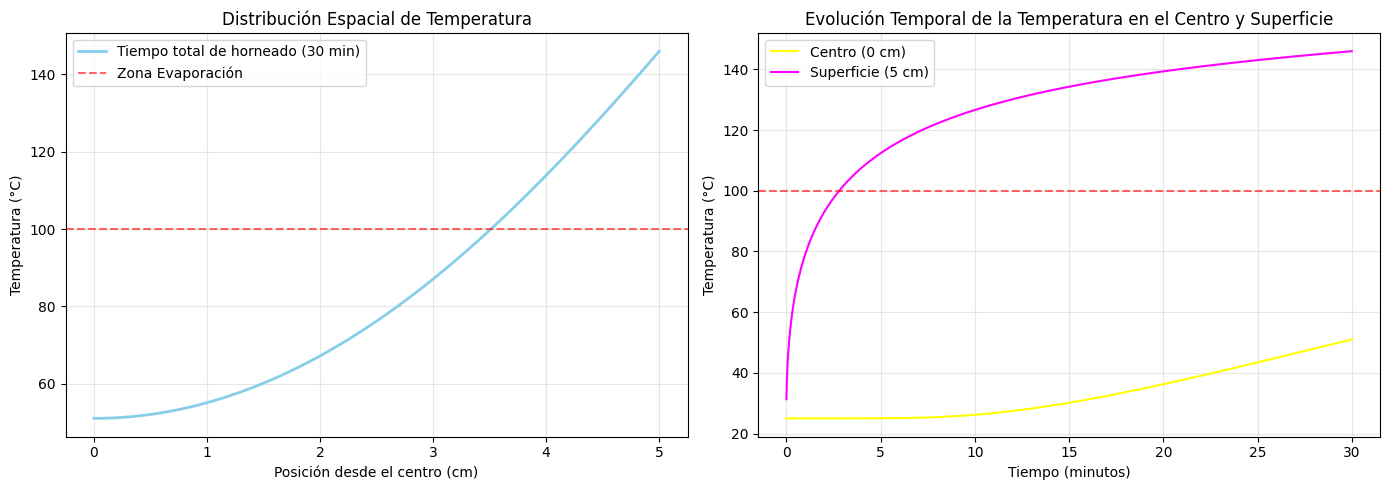

In [50]:
# --- VISUALIZACIÓN ---
tiempo_eje = np.linspace(0, t_max/60, Nt) # Eje de tiempo en minutos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Perfil de temperatura final (Posición)
x_cm = np.linspace(0, L, Nx) * 100
ax1.plot(x_cm, T, color='skyblue', lw=2, label='Tiempo total de horneado (30 min)')
ax1.axhline(100, color='red', linestyle='--', alpha=0.6, label='Zona Evaporación')
ax1.set_xlabel('Posición desde el centro (cm)')
ax1.set_ylabel('Temperatura (°C)')
ax1.set_title('Distribución Espacial de Temperatura')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico B: Evolución Temporal (Centro vs Borde)
ax2.plot(tiempo_eje, temp_centro, label='Centro (0 cm)', color='yellow')
ax2.plot(tiempo_eje, temp_superficie, label='Superficie (5 cm)', color='fuchsia')
ax2.axhline(100, color='red', linestyle='--', alpha=0.6)
ax2.set_xlabel('Tiempo (minutos)')
ax2.set_ylabel('Temperatura (°C)')
ax2.set_title('Evolución Temporal de la Temperatura en el Centro y Superficie')
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()
